In [ ]:
import sys, os
import numpy as np
sys.path.append(os.path.abspath(".."))

data = np.load("./data/processed/mitdb_preprocessed.npz")

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]
rec_train = data["rec_train"]
rec_test = data["rec_test"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train positives:", np.sum(y_train==1))
print("Test positives:", np.sum(y_test==1))

Train shape: (77518, 360)
Test shape: (35129, 360)
Train positives: 46054
Test positives: 28998


In [7]:
from src.legacy_cbms26.bags import generate_bags

bags_X_train, bags_prev_train = generate_bags(
  X_train, y_train,
  bag_size=100,
  n_bags=10000,         # Exemplo
  random_state=42
)

bags_X_test, bags_prev_test = generate_bags(
  X_test, y_test,
  bag_size=100,
  n_bags=10000,          # Exemplo
  random_state=123
)

print("N bags train:", len(bags_X_train))
print("N bags test:", len(bags_X_test))
print("Primeiras prevalências treino:", bags_prev_train[:5])

[INFO] Positive samples: 46054, Negative samples: 31464.
[INFO] Positive samples: 28998, Negative samples: 6131.
N bags train: 10000
N bags test: 10000
Primeiras prevalências treino: [0.77, 0.43, 0.85, 0.69, 0.09]


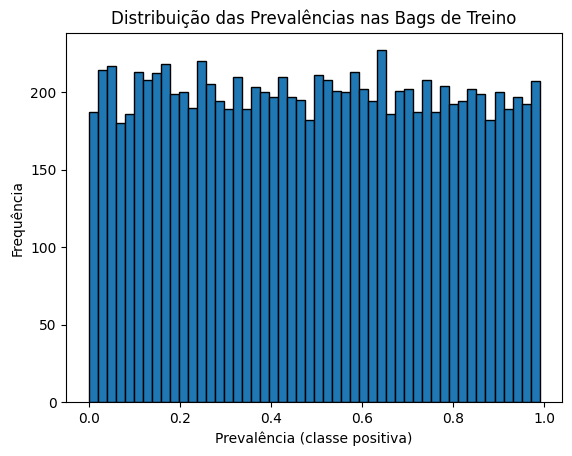

In [8]:
import matplotlib.pyplot as plt

plt.hist(bags_prev_train, bins=50, edgecolor='black')
plt.title("Distribuição das Prevalências nas Bags de Treino")
plt.xlabel("Prevalência (classe positiva)")
plt.ylabel("Frequência")
plt.show()

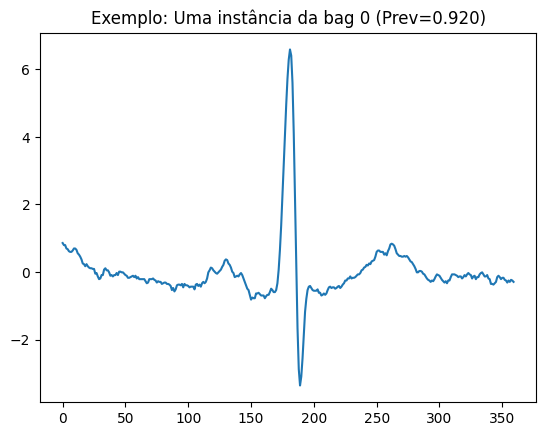

Shape da bag: (100, 360)


In [12]:
import matplotlib.pyplot as plt

idx = 11  # escolha uma bag

bag = bags_X_train[idx]
prev = bags_prev_train[idx]

plt.plot(bag[0])
plt.title(f"Exemplo: Uma instância da bag 0 (Prev={prev:.3f})")
plt.show()

print("Shape da bag:", bag.shape)